# Synthetic Market Data Generation

**A comprehensive guide to generating deterministic market data for FX, IR, and Equity**

This notebook demonstrates how to use the `SyntheticProvider` to generate market data for testing, development, and backtesting.

---

## Table of Contents

1. [Introduction](#1-introduction)
2. [Basic Usage](#2-basic-usage)
3. [FX Market Data](#3-fx-market-data)
4. [Interest Rate Curves](#4-interest-rate-curves)
5. [Equity Market Data](#5-equity-market-data)
6. [Multi-Asset Portfolios](#6-multi-asset-portfolios)
7. [Customization](#7-customization)
8. [Best Practices](#8-best-practices)

In [15]:
# Standard imports
import sys
sys.path.insert(0, '../../..')

import numpy as np
import matplotlib.pyplot as plt
from datetime import date

# QuantStrata imports
from src.marketdata.core.ids import MarketId
from src.marketdata.core.requests import MarketRequest, TimeseriesRequest, Universe
from src.marketdata.providers.synthetic.provider import SyntheticProvider
from src.marketdata.providers.synthetic.config import SyntheticProviderConfig
from src.marketdata.providers.synthetic.specs import SpotGbmSpec, CurveZeroSpec, VolGridSmileSpec

# Plot configuration
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.figsize': (12, 5),
    'font.size': 11,
    'axes.titlesize': 13,
    'lines.linewidth': 1.5,
})

print("Imports successful!")

Imports successful!


---

## 1. Introduction

### What is the SyntheticProvider?

The `SyntheticProvider` generates **deterministic, market-like data** for:
- **Testing**: Reproducible unit and integration tests
- **Development**: Work without live data feeds
- **Backtesting**: Monte Carlo scenario generation
- **Examples**: Documentation and demos

### Key Features

| Feature | Description |
|---------|-------------|
| **Determinism** | Same seed always produces identical data |
| **Dependency Closure** | VOL surfaces auto-request SPOT and curves |
| **Multi-Asset** | FX, IR, and Equity support |
| **Configurable** | Per-MarketId specification overrides |

---

## 2. Basic Usage

### Creating a Provider

In [16]:
# Create a provider with a fixed seed for reproducibility
provider = SyntheticProvider(seed=42)

print(f"Provider name: {provider.name}")
print(f"Seed: {provider.seed}")

Provider name: SyntheticProvider
Seed: 42


### Single Market Snapshot

In [17]:
# Define what we want
fx_spot_id = MarketId(
    asset_class="FX",
    mkt_type="SPOT",
    name="EURUSD",
    qualifiers=(("dom", "USD"), ("for", "EUR")),
)

# Request a single snapshot
market = provider.get_market(MarketRequest(
    asof=date(2026, 1, 15),
    universe=Universe([fx_spot_id]),
))

# Extract the spot rate
spot = market.quote(fx_spot_id)
print(f"EURUSD spot on 2026-01-15: {spot:.4f}")
print(f"As-of date: {market.asof}")

EURUSD spot on 2026-01-15: 1.1000
As-of date: 2026-01-15


### Time Series Generation

In [18]:
# Request a time series with multiple scenarios
dataset = provider.get_timeseries(TimeseriesRequest(
    start=date(2026, 1, 1),
    end=date(2026, 3, 31),  # 3 months
    freq="D",              # Daily
    universe=Universe([fx_spot_id]),
    scenarios=100,         # Monte Carlo scenarios
))

print(f"Dates: {len(dataset.dates)} days")
print(f"Scenarios: {dataset.n_scenarios}")
print(f"Date range: {dataset.dates[0]} to {dataset.dates[-1]}")

Dates: 90 days
Scenarios: 100
Date range: 2026-01-01 to 2026-03-31


Panel shape: (90, 100)
Axis names: ('time', 'scenario')


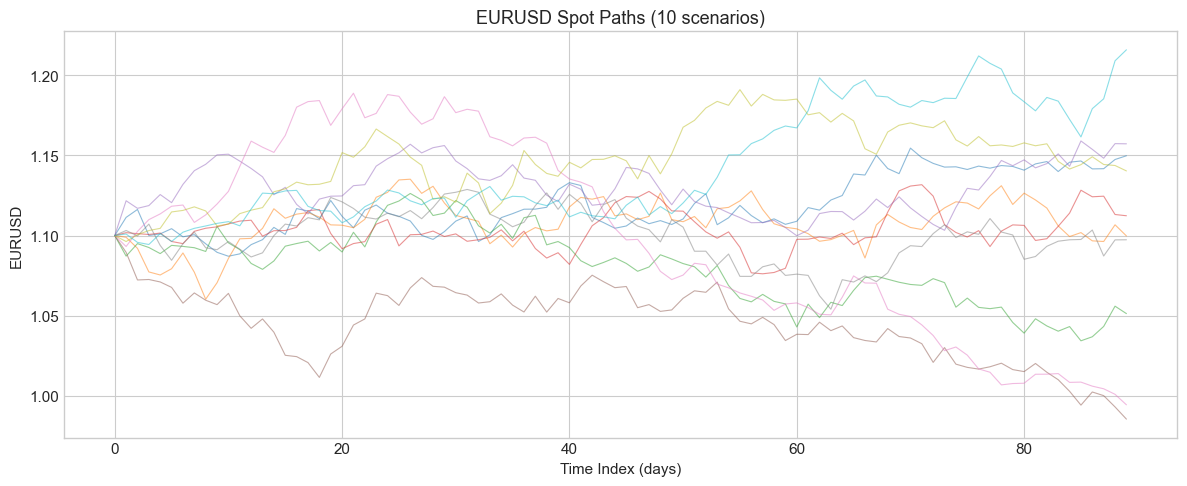

In [19]:
# Extract the spot panel
spot_panel = dataset.panels[fx_spot_id]
spot_data = spot_panel.data

print(f"Panel shape: {spot_data.shape}")
print(f"Axis names: {spot_panel.axis_names}")

# Plot scenarios
fig, ax = plt.subplots(figsize=(12, 5))

# Plot first 10 scenarios
for s in range(min(10, spot_data.shape[1])):
    ax.plot(spot_data[:, s], alpha=0.5, linewidth=0.8)

ax.set_xlabel('Time Index (days)')
ax.set_ylabel('EURUSD')
ax.set_title('EURUSD Spot Paths (10 scenarios)')
plt.tight_layout()
plt.show()

---

## 3. FX Market Data

### FX SPOT, VOL, and Curves

In [20]:
# Define FX universe with vol surface
fx_spot_id = MarketId("FX", "SPOT", "EURUSD", (("dom", "USD"), ("for", "EUR")))
fx_vol_id = MarketId("FX", "VOL", "EURUSD", (("dom", "USD"), ("for", "EUR")))

# Note: VOL will auto-request SPOT and IR curves (dependency closure)
dataset = provider.get_timeseries(TimeseriesRequest(
    start=date(2026, 1, 1),
    end=date(2026, 1, 31),
    freq="D",
    universe=Universe([fx_vol_id]),  # Only request VOL - dependencies added automatically
    scenarios=50,
))

print("Generated MarketIds:")
for mid in dataset.panels.keys():
    print(f"  - {mid.key()}")
for mid in dataset.curve_params.keys():
    print(f"  - {mid.key()} (curve)")
for mid in dataset.vol_params.keys():
    print(f"  - {mid.key()} (vol surface)")

Generated MarketIds:
  - FX.SPOT.EURUSD|dom=USD|for=EUR
  - IR.CURVE.EUR.OIS|ccy=EUR (curve)
  - IR.CURVE.USD.OIS|ccy=USD (curve)
  - FX.VOL.EURUSD|dom=USD|for=EUR (vol surface)


In [21]:
# Extract a market snapshot
market = dataset.snapshot(time_idx=15, scenario_idx=0)

# Get vol surface
vol_surface = market.vol_surface(fx_vol_id)

# Query implied vol at various strikes and expiries
spot = market.quote(fx_spot_id)
print(f"\nSpot: {spot:.4f}")
print("\nImplied Volatility Surface:")
print(f"{'Expiry':<10} {'K=0.95*S':<12} {'K=S (ATM)':<12} {'K=1.05*S':<12}")
print("-" * 46)

for T in [0.25, 0.5, 1.0]:
    vol_low = vol_surface.vol(T, spot * 0.95)
    vol_atm = vol_surface.vol(T, spot)
    vol_high = vol_surface.vol(T, spot * 1.05)
    print(f"{T:<10.2f} {vol_low:<12.2%} {vol_atm:<12.2%} {vol_high:<12.2%}")


Spot: 1.1061

Implied Volatility Surface:
Expiry     K=0.95*S     K=S (ATM)    K=1.05*S    
----------------------------------------------
0.25       11.38%       11.34%       11.36%      
0.50       11.87%       11.69%       11.53%      
1.00       12.25%       12.10%       11.69%      


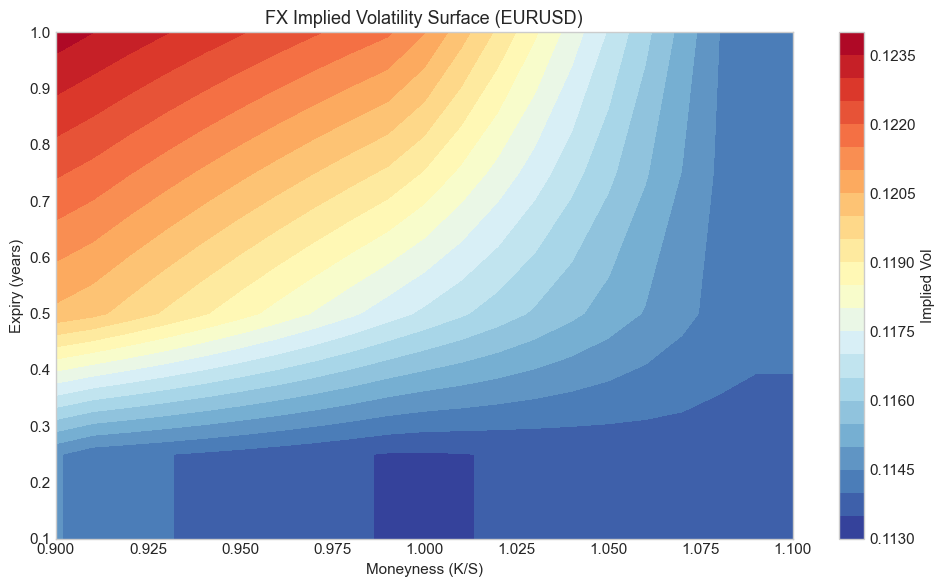

In [22]:
# Visualize the vol surface
expiries = np.array([0.1, 0.25, 0.5, 0.75, 1.0])
moneyness = np.linspace(0.9, 1.1, 21)
strikes = spot * moneyness

vol_grid = np.zeros((len(expiries), len(strikes)))
for i, T in enumerate(expiries):
    for j, K in enumerate(strikes):
        vol_grid[i, j] = vol_surface.vol(T, K)

fig, ax = plt.subplots(figsize=(10, 6))
cs = ax.contourf(moneyness, expiries, vol_grid, levels=20, cmap='RdYlBu_r')
ax.set_xlabel('Moneyness (K/S)')
ax.set_ylabel('Expiry (years)')
ax.set_title('FX Implied Volatility Surface (EURUSD)')
plt.colorbar(cs, label='Implied Vol')
plt.tight_layout()
plt.show()

---

## 4. Interest Rate Curves

### Generating Zero Rate Curves

In [23]:
# Define IR curve
usd_curve_id = MarketId("IR", "CURVE", "USD.OIS", (("ccy", "USD"),))

# Generate
dataset = provider.get_timeseries(TimeseriesRequest(
    start=date(2026, 1, 1),
    end=date(2026, 12, 31),
    freq="W",  # Weekly
    universe=Universe([usd_curve_id]),
    scenarios=20,
))

print(f"Dates: {len(dataset.dates)} weeks")
print(f"Curve params shape: {dataset.curve_params[usd_curve_id].data.shape}")

Dates: 53 weeks
Curve params shape: (53, 20, 5, 2)


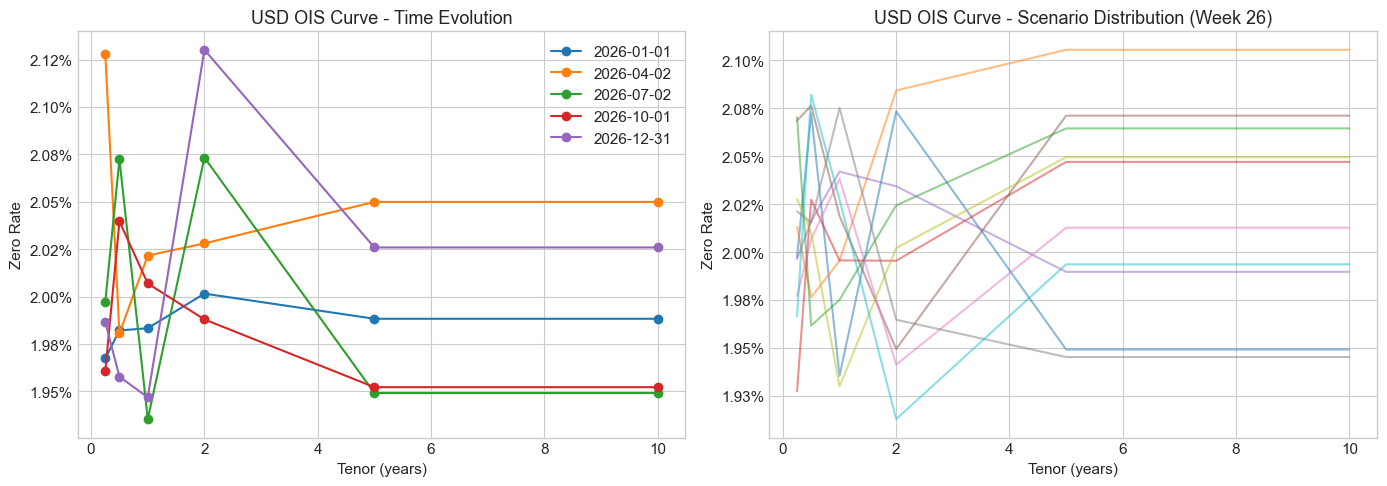

In [24]:
# Extract curve at different dates
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot curves at different times (same scenario)
tenors = np.array([0.25, 0.5, 1.0, 2.0, 5.0, 10.0])

ax = axes[0]
for t_idx in [0, 13, 26, 39, 52]:
    if t_idx >= len(dataset.dates):
        continue
    market = dataset.snapshot(time_idx=t_idx, scenario_idx=0)
    curve = market.curve(usd_curve_id)
    rates = [curve.zero_rate(tau) for tau in tenors]
    ax.plot(tenors, rates, 'o-', label=f'{dataset.dates[t_idx]}')

ax.set_xlabel('Tenor (years)')
ax.set_ylabel('Zero Rate')
ax.set_title('USD OIS Curve - Time Evolution')
ax.legend()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.2%}'))

# Plot curves across scenarios (same time)
ax = axes[1]
for s_idx in range(min(10, dataset.n_scenarios)):
    market = dataset.snapshot(time_idx=26, scenario_idx=s_idx)
    curve = market.curve(usd_curve_id)
    rates = [curve.zero_rate(tau) for tau in tenors]
    ax.plot(tenors, rates, alpha=0.5)

ax.set_xlabel('Tenor (years)')
ax.set_ylabel('Zero Rate')
ax.set_title('USD OIS Curve - Scenario Distribution (Week 26)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.2%}'))

plt.tight_layout()
plt.show()

---

## 5. Equity Market Data

### Equity SPOT and VOL

In [25]:
# Define equity universe
aapl_spot_id = MarketId("EQUITY", "SPOT", "AAPL", (("ccy", "USD"),))
aapl_vol_id = MarketId("EQUITY", "VOL", "AAPL", (("ccy", "USD"),))

# Generate (VOL will auto-request SPOT)
dataset = provider.get_timeseries(TimeseriesRequest(
    start=date(2026, 1, 1),
    end=date(2026, 6, 30),
    freq="D",
    universe=Universe([aapl_vol_id]),
    scenarios=100,
))

print(f"Generated {len(dataset.dates)} days, {dataset.n_scenarios} scenarios")

Generated 181 days, 100 scenarios


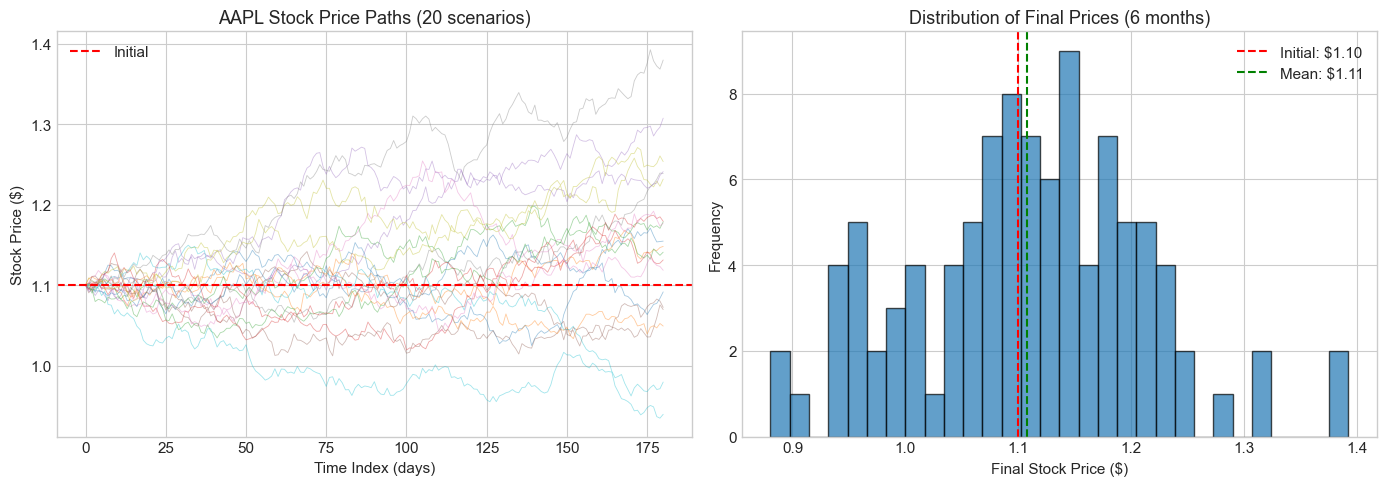

In [26]:
# Plot equity paths
spot_data = dataset.panels[aapl_spot_id].data

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Spot paths
ax = axes[0]
for s in range(min(20, spot_data.shape[1])):
    ax.plot(spot_data[:, s], alpha=0.4, linewidth=0.6)
ax.axhline(spot_data[0, 0], color='red', linestyle='--', label='Initial')
ax.set_xlabel('Time Index (days)')
ax.set_ylabel('Stock Price ($)')
ax.set_title('AAPL Stock Price Paths (20 scenarios)')
ax.legend()

# Final distribution
ax = axes[1]
final_prices = spot_data[-1, :]
ax.hist(final_prices, bins=30, edgecolor='black', alpha=0.7)
ax.axvline(spot_data[0, 0], color='red', linestyle='--', label=f'Initial: ${spot_data[0,0]:.2f}')
ax.axvline(np.mean(final_prices), color='green', linestyle='--', label=f'Mean: ${np.mean(final_prices):.2f}')
ax.set_xlabel('Final Stock Price ($)')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of Final Prices (6 months)')
ax.legend()

plt.tight_layout()
plt.show()

In [27]:
# Equity vol surface (strike-based with negative skew)
market = dataset.snapshot(time_idx=60, scenario_idx=0)
spot = market.quote(aapl_spot_id)
vol_surface = market.vol_surface(aapl_vol_id)

print(f"Spot: ${spot:.2f}")
print("\nEquity Implied Volatility (negative skew pattern):")
print(f"{'Expiry':<10} {'80% K':<12} {'90% K':<12} {'ATM':<12} {'110% K':<12} {'120% K':<12}")
print("-" * 70)

for T in [0.25, 0.5, 1.0]:
    vols = [vol_surface.vol(T, spot * m) for m in [0.8, 0.9, 1.0, 1.1, 1.2]]
    print(f"{T:<10.2f} {vols[0]:<12.2%} {vols[1]:<12.2%} {vols[2]:<12.2%} {vols[3]:<12.2%} {vols[4]:<12.2%}")

Spot: $1.14

Equity Implied Volatility (negative skew pattern):
Expiry     80% K        90% K        ATM          110% K       120% K      
----------------------------------------------------------------------
0.25       11.80%       11.50%       11.14%       10.80%       10.80%      
0.50       12.25%       11.84%       11.65%       11.63%       11.63%      
1.00       12.48%       12.27%       12.05%       11.82%       11.82%      


---

## 6. Multi-Asset Portfolios

### Generating Data for Multiple Assets

In [28]:
# Define a multi-asset universe
universe = [
    # FX pairs
    MarketId("FX", "VOL", "EURUSD", (("dom", "USD"), ("for", "EUR"))),
    MarketId("FX", "VOL", "GBPUSD", (("dom", "USD"), ("for", "GBP"))),
    MarketId("FX", "VOL", "USDJPY", (("dom", "JPY"), ("for", "USD"))),
    
    # Equities
    MarketId("EQUITY", "VOL", "AAPL", (("ccy", "USD"),)),
    MarketId("EQUITY", "VOL", "MSFT", (("ccy", "USD"),)),
    MarketId("EQUITY", "VOL", "SPX", (("ccy", "USD"),)),
]

# Generate
dataset = provider.get_timeseries(TimeseriesRequest(
    start=date(2026, 1, 1),
    end=date(2026, 1, 31),
    freq="D",
    universe=Universe(universe),
    scenarios=50,
))

print("Generated MarketIds:")
print(f"\nQuotes ({len(dataset.panels)}):")
for mid in sorted(dataset.panels.keys(), key=lambda m: m.key()):
    print(f"  - {mid.key()}")

print(f"\nCurves ({len(dataset.curve_params)}):")
for mid in sorted(dataset.curve_params.keys(), key=lambda m: m.key()):
    print(f"  - {mid.key()}")

print(f"\nVol Surfaces ({len(dataset.vol_params)}):")
for mid in sorted(dataset.vol_params.keys(), key=lambda m: m.key()):
    print(f"  - {mid.key()}")

Generated MarketIds:

Quotes (6):
  - EQUITY.SPOT.AAPL|ccy=USD
  - EQUITY.SPOT.MSFT|ccy=USD
  - EQUITY.SPOT.SPX|ccy=USD
  - FX.SPOT.EURUSD|dom=USD|for=EUR
  - FX.SPOT.GBPUSD|dom=USD|for=GBP
  - FX.SPOT.USDJPY|dom=JPY|for=USD

Curves (4):
  - IR.CURVE.EUR.OIS|ccy=EUR
  - IR.CURVE.GBP.OIS|ccy=GBP
  - IR.CURVE.JPY.OIS|ccy=JPY
  - IR.CURVE.USD.OIS|ccy=USD

Vol Surfaces (6):
  - EQUITY.VOL.AAPL|ccy=USD
  - EQUITY.VOL.MSFT|ccy=USD
  - EQUITY.VOL.SPX|ccy=USD
  - FX.VOL.EURUSD|dom=USD|for=EUR
  - FX.VOL.GBPUSD|dom=USD|for=GBP
  - FX.VOL.USDJPY|dom=JPY|for=USD


---

## 7. Customization

### Custom Configuration

In [29]:
# Create custom configuration
custom_config = SyntheticProviderConfig(
    # Custom spot generation
    spot=SpotGbmSpec(
        initial_level=150.0,  # Higher initial level
        drift=0.08,           # 8% drift
        vol=0.25,             # 25% volatility
        dt=1.0 / 252.0,
    ),
    
    # Custom curve shape
    curve_zero=CurveZeroSpec(
        tenors=np.array([0.25, 0.5, 1.0, 2.0, 5.0, 10.0, 30.0]),
        base_rate=0.04,     # 4% base rate
        slope=0.005,        # Upward sloping
        curvature=0.01,     # Short-end hump
        noise_scale=0.001,
    ),
    
    # Custom vol surface
    vol=VolGridSmileSpec(
        expiries=np.array([0.1, 0.25, 0.5, 1.0, 2.0]),
        strikes=np.array([0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3]),
        atm_vol=0.25,       # 25% ATM vol
        skew=-0.20,         # Strong negative skew
        smile=0.10,
    ),
)

# Create provider with custom config
custom_provider = SyntheticProvider(seed=99, config=custom_config)

print("Custom provider created with:")
print(f"  - Initial spot: {custom_config.spot.initial_level}")
print(f"  - Spot vol: {custom_config.spot.vol:.0%}")
print(f"  - Base rate: {custom_config.curve_zero.base_rate:.1%}")
print(f"  - ATM vol: {custom_config.vol.atm_vol:.0%}")

Custom provider created with:
  - Initial spot: 150.0
  - Spot vol: 25%
  - Base rate: 4.0%
  - ATM vol: 25%


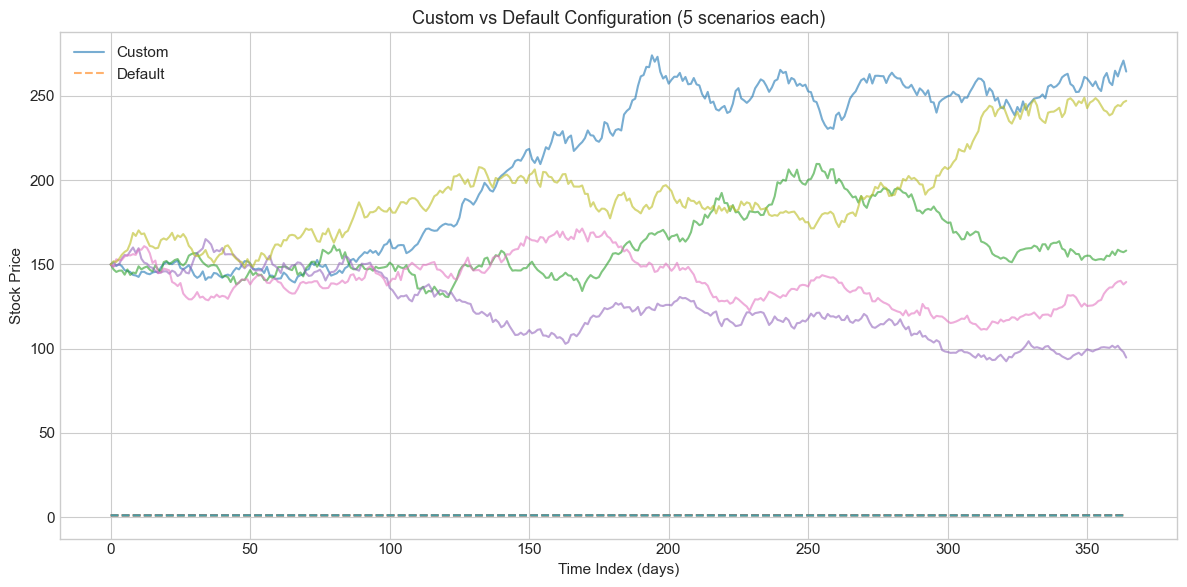

In [30]:
# Generate with custom config
custom_spot_id = MarketId("EQUITY", "SPOT", "CUSTOM")

custom_dataset = custom_provider.get_timeseries(TimeseriesRequest(
    start=date(2026, 1, 1),
    end=date(2026, 12, 31),
    freq="D",
    universe=Universe([custom_spot_id]),
    scenarios=100,
))

# Compare with default
default_provider = SyntheticProvider(seed=99)
default_spot_id = MarketId("EQUITY", "SPOT", "DEFAULT")

default_dataset = default_provider.get_timeseries(TimeseriesRequest(
    start=date(2026, 1, 1),
    end=date(2026, 12, 31),
    freq="D",
    universe=Universe([default_spot_id]),
    scenarios=100,
))

# Plot comparison
fig, ax = plt.subplots(figsize=(12, 6))

custom_data = custom_dataset.panels[custom_spot_id].data
default_data = default_dataset.panels[default_spot_id].data

for s in range(5):
    ax.plot(custom_data[:, s], alpha=0.6, label='Custom' if s == 0 else None)
    ax.plot(default_data[:, s], alpha=0.6, linestyle='--', label='Default' if s == 0 else None)

ax.set_xlabel('Time Index (days)')
ax.set_ylabel('Stock Price')
ax.set_title('Custom vs Default Configuration (5 scenarios each)')
ax.legend()
plt.tight_layout()
plt.show()

---

## 8. Best Practices

### Reproducibility

In [31]:
# Same seed = same data
provider1 = SyntheticProvider(seed=123)
provider2 = SyntheticProvider(seed=123)

test_id = MarketId("FX", "SPOT", "EURUSD")

ds1 = provider1.get_timeseries(TimeseriesRequest(
    start=date(2026, 1, 1), end=date(2026, 1, 10), freq="D",
    universe=Universe([test_id]), scenarios=5,
))

ds2 = provider2.get_timeseries(TimeseriesRequest(
    start=date(2026, 1, 1), end=date(2026, 1, 10), freq="D",
    universe=Universe([test_id]), scenarios=5,
))

# Verify identical
data1 = ds1.panels[test_id].data
data2 = ds2.panels[test_id].data

print(f"Data identical: {np.allclose(data1, data2)}")
print(f"Max difference: {np.max(np.abs(data1 - data2))}")

Data identical: True
Max difference: 0.0


In [32]:
# Different MarketIds get independent RNG streams
id1 = MarketId("FX", "SPOT", "EURUSD")
id2 = MarketId("FX", "SPOT", "GBPUSD")

ds = provider1.get_timeseries(TimeseriesRequest(
    start=date(2026, 1, 1), end=date(2026, 1, 10), freq="D",
    universe=Universe([id1, id2]), scenarios=5,
))

data1 = ds.panels[id1].data
data2 = ds.panels[id2].data

correlation = np.corrcoef(data1.flatten(), data2.flatten())[0, 1]
print(f"Correlation between EURUSD and GBPUSD: {correlation:.4f}")
print("(Near zero = independent RNG streams)")

Correlation between EURUSD and GBPUSD: 0.5427
(Near zero = independent RNG streams)


### Summary

**Key Takeaways:**

1. **Use fixed seeds** for reproducible tests
2. **Let dependency closure** handle prerequisites (just request VOL, get SPOT and curves)
3. **Customize via config** for specific test scenarios
4. **Extract snapshots** for pricing with `dataset.snapshot(time_idx, scenario_idx)`
5. **Different MarketIds** produce independent random streams